In [104]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [105]:
# by STEFAN SMID
# read file from Github

username = "datagus"
repository = "ASDA2025"
directory = "datasets/Fish.csv"
file_path = f"https://raw.githubusercontent.com/{username}/{repository}/main/{directory}"

In [106]:
fish_df = pd.read_csv(file_path)
fish_df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [107]:
# first basic data exploration
fish_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [108]:
# descriptive statistics
fish_df.describe()

# converting into a dataframe
desc_stats = fish_df.describe()

# round to 2 decimal places
desc_stats = desc_stats.round(2)
print(desc_stats.to_markdown())

|       |   Weight |   Length1 |   Length2 |   Length3 |   Height |   Width |
|:------|---------:|----------:|----------:|----------:|---------:|--------:|
| count |   159    |    159    |    159    |    159    |   159    |  159    |
| mean  |   398.33 |     26.25 |     28.42 |     31.23 |     8.97 |    4.42 |
| std   |   357.98 |     10    |     10.72 |     11.61 |     4.29 |    1.69 |
| min   |     0    |      7.5  |      8.4  |      8.8  |     1.73 |    1.05 |
| 25%   |   120    |     19.05 |     21    |     23.15 |     5.94 |    3.39 |
| 50%   |   273    |     25.2  |     27.3  |     29.4  |     7.79 |    4.25 |
| 75%   |   650    |     32.7  |     35.5  |     39.65 |    12.37 |    5.58 |
| max   |  1650    |     59    |     63.4  |     68    |    18.96 |    8.14 |


In [109]:
fish_df.columns

Index(['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height',
       'Width'],
      dtype='object')

In [110]:
# List of category columns excluding 'code'
category_columns = [col for col in ['Species'] if col in fish_df.columns]

# Build category summary
cat_summary = {}

for col in category_columns:
    vc = fish_df[col].value_counts(dropna=False)
    cat_summary[col] = [
        fish_df[col].count(),
        fish_df[col].nunique(dropna=False),
        vc.idxmax(),
        vc.max(),
        vc.idxmin(),
        vc.min()
    ]

# Create DataFrame
cat_summary_table = pd.DataFrame(
    cat_summary,
    index=[
        'Count',
        'Number of unique values',
        'Most frequent value',
        'Most frequent value (frequency)',
        'Least frequent value',
        'Least frequent value (frequency)'
    ]
)

# Display as markdown
print(cat_summary_table.to_markdown())

|                                  | Species   |
|:---------------------------------|:----------|
| Count                            | 159       |
| Number of unique values          | 7         |
| Most frequent value              | Perch     |
| Most frequent value (frequency)  | 56        |
| Least frequent value             | Whitefish |
| Least frequent value (frequency) | 6         |


In [111]:
# check for missing values
fish_df.isnull().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [112]:
# Check for duplicate rows
fish_df.duplicated().any()

False

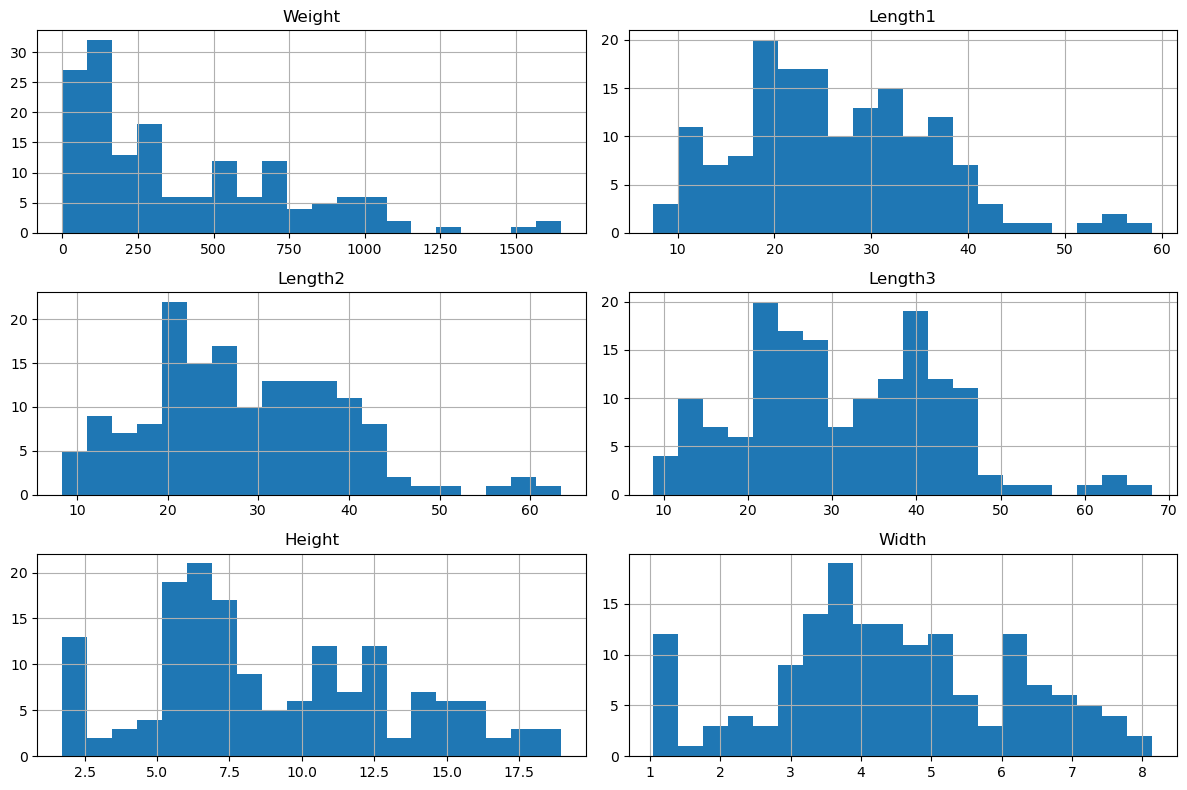

In [ ]:
fish_df.hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()


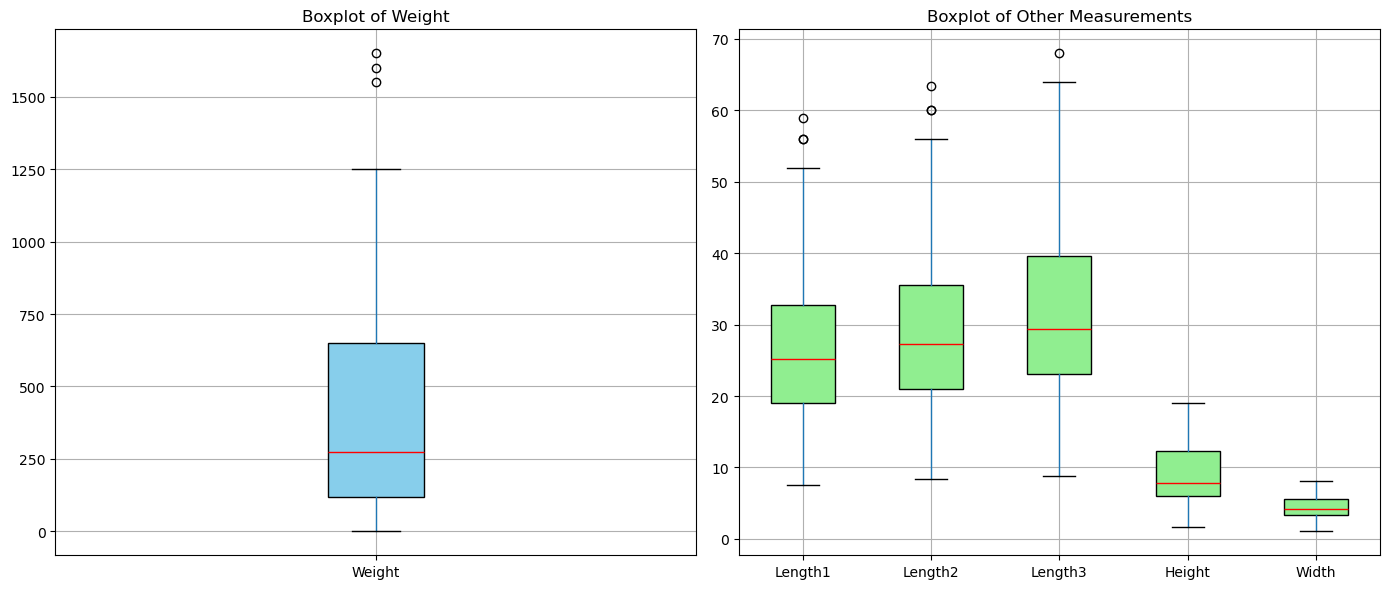

In [385]:
numeric_cols = fish_df.select_dtypes(include="number").columns.tolist()
other_cols = [col for col in numeric_cols if col != "Weight"]
# Create figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot for Weight
fish_df.boxplot(column="Weight", ax=axes[0], patch_artist=True,
                boxprops=dict(facecolor="skyblue", color="black"),
                medianprops=dict(color="red"))
axes[0].set_title("Boxplot of Weight")

# Boxplot for other numeric columns
fish_df.boxplot(column=other_cols, ax=axes[1], patch_artist=True,
                boxprops=dict(facecolor="lightgreen", color="black"),
                medianprops=dict(color="red"))
axes[1].set_title("Boxplot of Other Measurements")

plt.tight_layout()
plt.show()

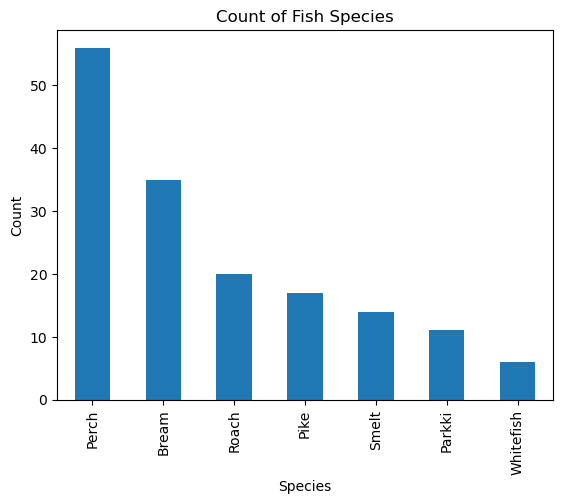

In [386]:
fish_df["Species"].value_counts().plot(kind="bar")
plt.xlabel("Species")
plt.ylabel("Count")
plt.title("Count of Fish Species")
plt.show()


## 5. Analysis - Research question

### 1. Question/hypothesis
Hypothesis: The weight of fish can be estimated based on their length, width, and height.

### 2. Check assumptions: normal distribution of dependent variable?

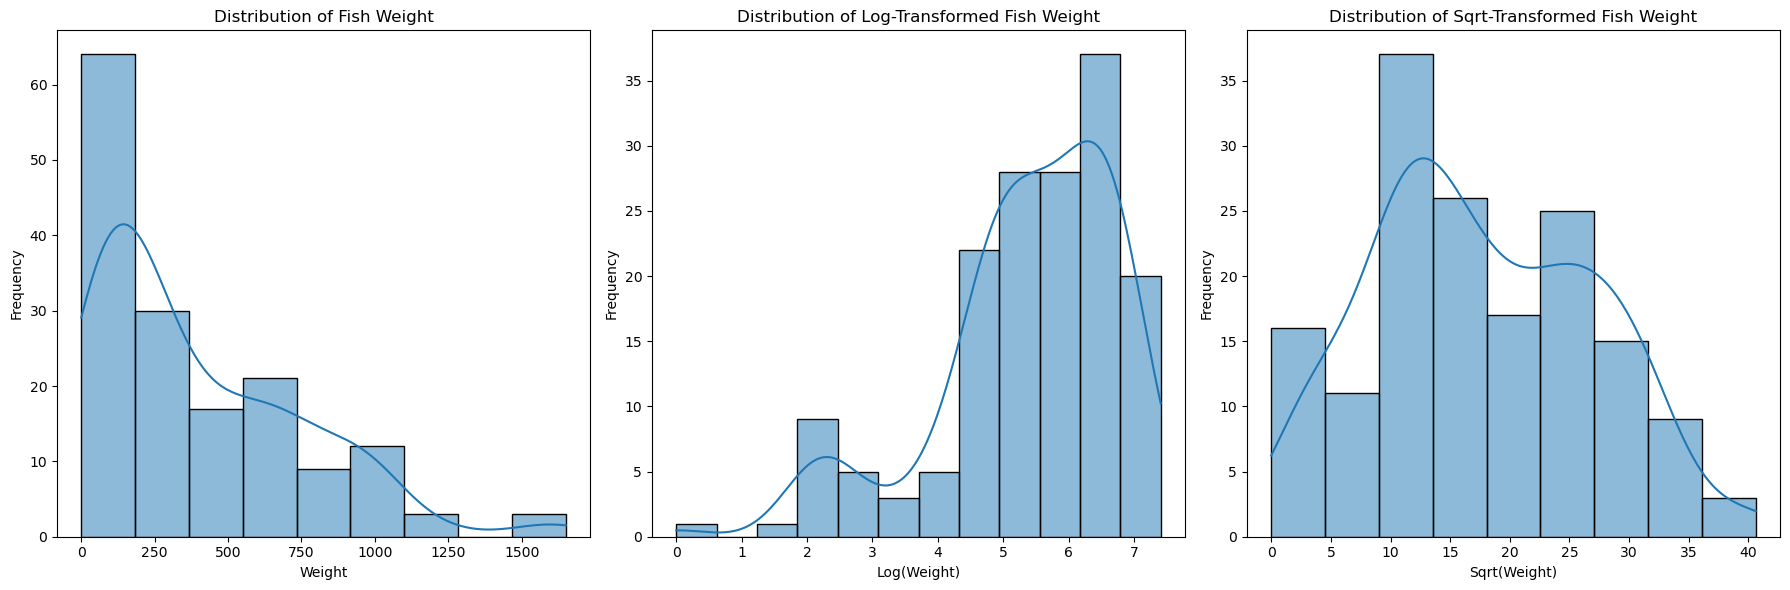

In [387]:
# weight is dependent variable
# as a tight matplotlib subplot layout

# Create a 1x3 subplot layout
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
sns.histplot(fish_df['Weight'], kde=True)
plt.title('Distribution of Fish Weight')
plt.xlabel('Weight')
plt.ylabel('Frequency')

# log transformation is needed

# log plot
plt.subplot(1, 3, 2)
log_df = fish_df.copy()
log_df['Weight'] = log_df['Weight'].apply(lambda x: np.log(x) if x > 0 else 0)
sns.histplot(log_df['Weight'], kde=True)
plt.title('Distribution of Log-Transformed Fish Weight')
plt.xlabel('Log(Weight)')
plt.ylabel('Frequency')

# add sqrt plot as well
plt.subplot(1, 3, 3)
sqrt_df = fish_df.copy()
sqrt_df['Weight'] = sqrt_df['Weight'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)
sns.histplot(sqrt_df['Weight'], kde=True)
plt.title('Distribution of Sqrt-Transformed Fish Weight')
plt.xlabel('Sqrt(Weight)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Answer: The dependent variable is not normally distributed and only the sqrt transformation yields a more symmetric distribution. Thus, we will proceed with the sqrt transformed weight and check the residual distributions later.

### 3. Check assumptions: multicollinearity (= redundancies among predictors)?

In [388]:
# Calculate the correlation matrix without categorical variables
correlation_matrix = sqrt_df.select_dtypes(include=['number']).corr()
correlation_matrix

,Weight,Length1,Length2,Length3,Height,Width
Weight,1.000000,0.937446,0.942553,0.954122,0.807993,0.948382
Length1,0.937446,1.000000,0.999517,0.992031,0.625378,0.867050
Length2,0.942553,0.999517,1.000000,0.994103,0.640441,0.873547
Length3,0.954122,0.992031,0.994103,1.000000,0.703409,0.878520
Height,0.807993,0.625378,0.640441,0.703409,1.000000,0.792881
Width,0.948382,0.867050,0.873547,0.878520,0.792881,1.000000


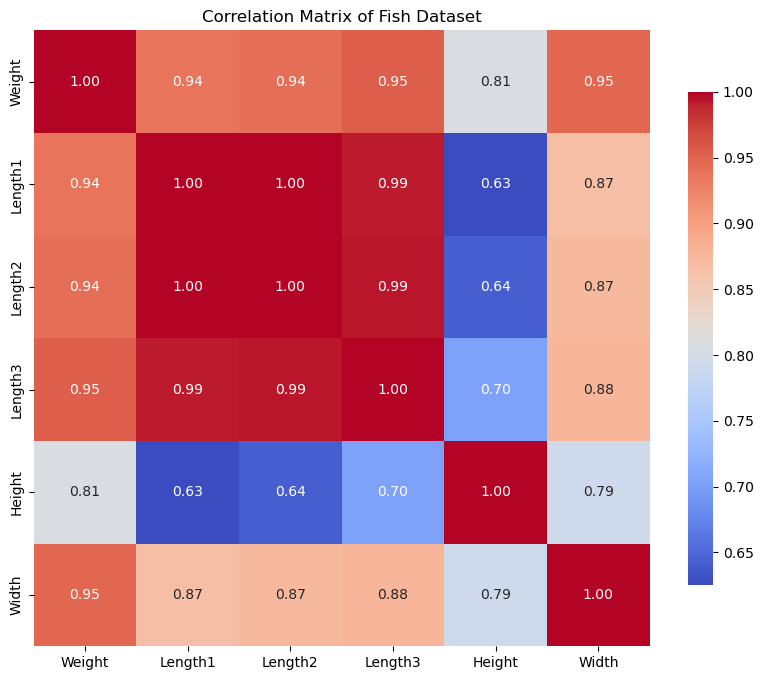

In [389]:
# Set up the matplotlib figure
plt.figure(figsize=(10, 8))
# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Fish Dataset')
plt.show()

In [390]:
def calculate_vif(X):
    vif = pd.DataFrame()
    vif["Variable"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif

# Select only numerical columns for VIF calculation
numerical_df = sqrt_df.select_dtypes(include=['number'])
vif_df = calculate_vif(numerical_df)

# riounded to 2 decimal places
vif_df = vif_df.round(2)
print(vif_df.to_markdown())

|    | Variable   |      VIF |
|---:|:-----------|---------:|
|  0 | Weight     |    55.11 |
|  1 | Length1    | 13608    |
|  2 | Length2    | 16752.3  |
|  3 | Length3    |  3561.2  |
|  4 | Height     |    91.38 |
|  5 | Width      |    93.16 |


In [391]:
# dropping Length1 and Length2 while Length3 is kept as it is the most representative length measure (combination of both)
sqrt_df_reduced = sqrt_df.drop(columns=['Length1', 'Length2'])
sqrt_df_reduced.head()

,Species,Weight,Length3,Height,Width
0,Bream,15.556349,30.0,11.5200,4.0200
1,Bream,17.029386,31.2,12.4800,4.3056
2,Bream,18.439089,31.1,12.3778,4.6961
3,Bream,19.052559,33.5,12.7300,4.4555
4,Bream,20.736441,34.0,12.4440,5.1340


In [392]:
# Recalculate VIF after dropping redundant variables
numerical_df_reduced = sqrt_df_reduced.select_dtypes(include=['number'])
vif_df_reduced = calculate_vif(numerical_df_reduced)

# riounded to 2 decimal places
vif_df_reduced = vif_df_reduced.round(2)
print(vif_df_reduced.to_markdown())

|    | Variable   |   VIF |
|---:|:-----------|------:|
|  0 | Weight     | 47.88 |
|  1 | Length3    | 45.16 |
|  2 | Height     | 15.65 |
|  3 | Width      | 52.02 |


Still high VIF for all variables, but much better now.
We do proceed with the reduced dataset for further analysis.

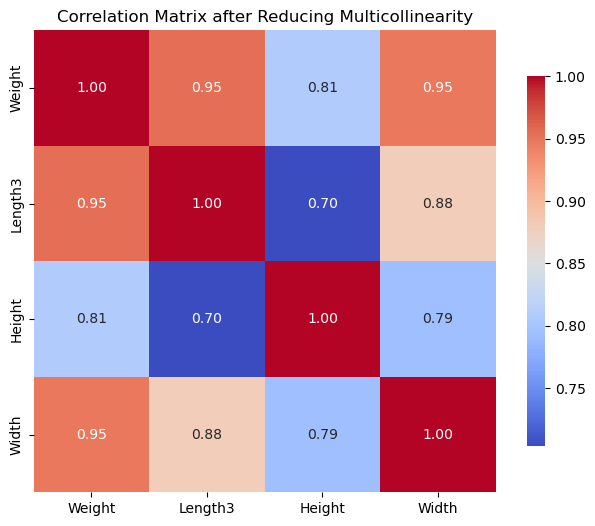

In [393]:
# Final correlation matrix after dropping redundant variables
correlation_matrix_reduced = numerical_df_reduced.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_reduced, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix after Reducing Multicollinearity')
plt.show()

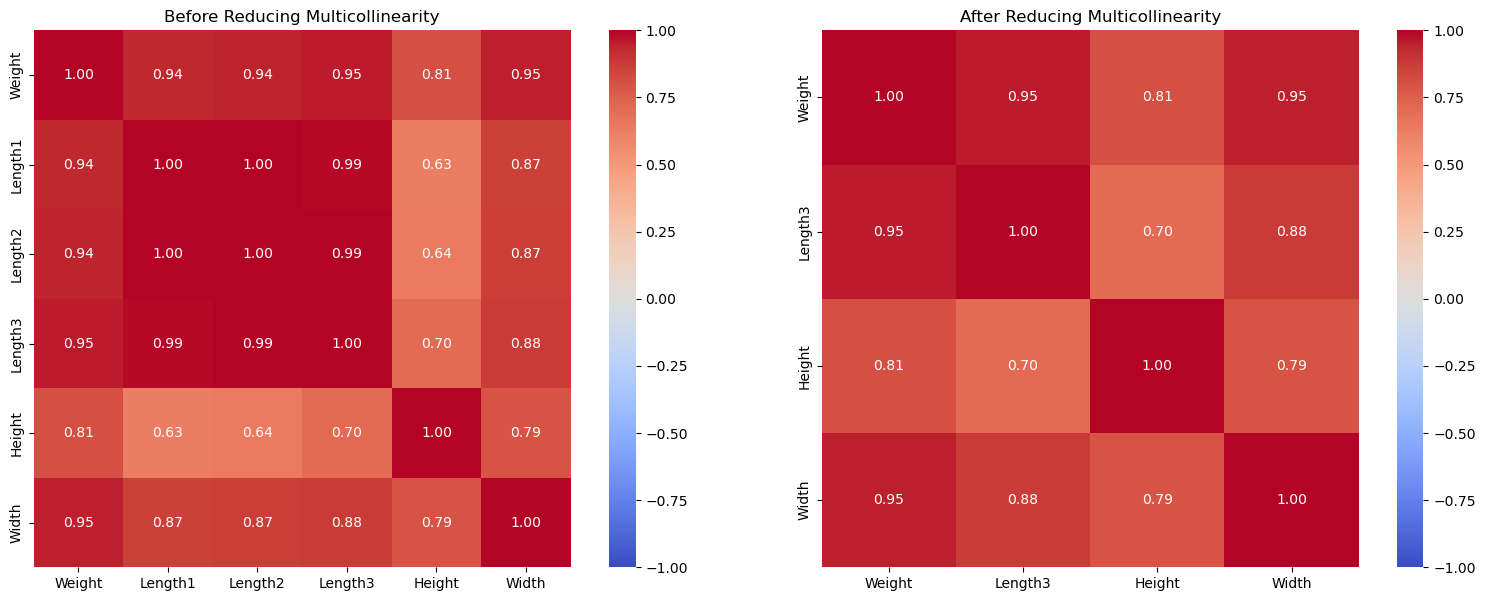

In [394]:
# plot a matplotlib tight plot subplot with two plots one being the corrmatrix before, one the one after reducing multicollinearity
# set colorbar from -1 to 1 for both plots using , vmax=1, vmin=-1, center=0
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, vmax=1, vmin=-1, center=0)
plt.title('Before Reducing Multicollinearity')

plt.subplot(1, 2, 2)
sns.heatmap(correlation_matrix_reduced, annot=True, fmt=".2f", cmap='coolwarm', square=True, vmax=1, vmin=-1, center=0)
plt.title('After Reducing Multicollinearity')

plt.tight_layout()
plt.show()

### 4. Split the data in train and test data

In [ ]:
#X = numerical_df_reduced.drop(columns=['Weight'])
#y = numerical_df_reduced['Weight']
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#print(f"Training set size: {X_train.shape[0]} samples")
#print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 127 samples
Test set size: 32 samples


(Testing with sqrt weight)

In [412]:
# Apply square root transformation to Weight
numerical_df_reduced['SqrtWeight'] = np.sqrt(numerical_df_reduced['Weight'])

# Define features (X) and new target (y)
X = numerical_df_reduced.drop(columns=['Weight', 'SqrtWeight'])
y = numerical_df_reduced['SqrtWeight']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 127 samples
Test set size: 32 samples


### 5. Preprocess the data:
- scale the numerical predictors - if you include multiple numerical predictors
- one hot encode the categorical predictors - if you include categorical predictors


In [413]:
# Preprocessing the data:
#   scale the numerical predictors - as we include multiple numerical predictors in this model

# Define the preprocessing steps
numeric_features = X.select_dtypes(include=['number']).columns.tolist()

# Create the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
    ])

# Fit and transform the training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print("Preprocessing complete.")

Preprocessing complete.


### 6. Train linear regression on training set

In [414]:
# Training linear regression on training set

model = LinearRegression()
model.fit(X_train_processed, y_train)
print("Model training complete.")

Model training complete.


### 7. Predict on test set and evaluate with metrics (e.g. MAE, RMSE, MAPE, R2))

In [415]:
y_pred = model.predict(X_test_processed)

# Calculate evaluation metrics
MAE = np.mean(np.abs(y_test - y_pred))
RMSE = np.sqrt(mean_squared_error(y_test, y_pred)) # Root Mean Squared Error (RMSE)
MAPE = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
R2 = r2_score(y_test, y_pred)

# rounding each to 2 decimal places and print as markdown table
metrics_df = pd.DataFrame({
    "Metric": ["Mean Absolute Error (MAE)", "Root Mean Squared Error (RMSE)", "Mean Absolute Percentage Error (MAPE)", "R^2 Score"],
    "Value": [MAE, RMSE, MAPE, R2]
})

print(metrics_df.round(2).to_markdown())

|    | Metric                                |   Value |
|---:|:--------------------------------------|--------:|
|  0 | Mean Absolute Error (MAE)             |    0.14 |
|  1 | Root Mean Squared Error (RMSE)        |    0.17 |
|  2 | Mean Absolute Percentage Error (MAPE) |    3.97 |
|  3 | R^2 Score                             |    0.98 |


Plots

- scatterplot with regression line
- actual vs. predicted values
- histogram of residuals: normal distribution? → if not, investigate why not?

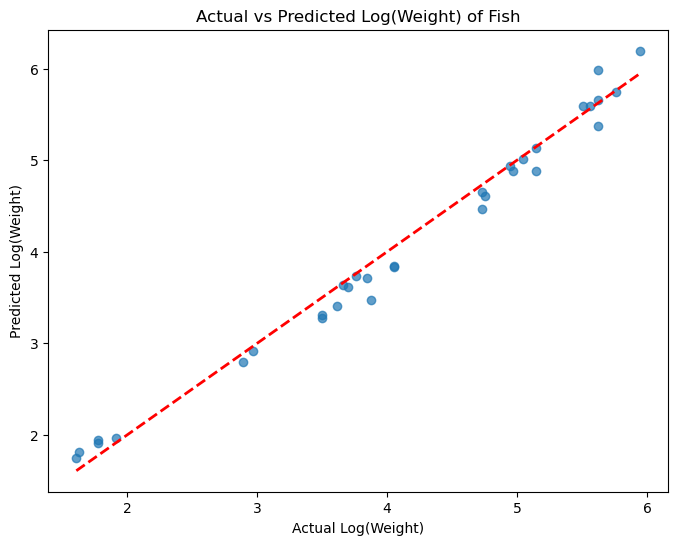

In [416]:
# Visualizing the predicted vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Log(Weight)')
plt.ylabel('Predicted Log(Weight)')
plt.title('Actual vs Predicted Log(Weight) of Fish')
plt.show()

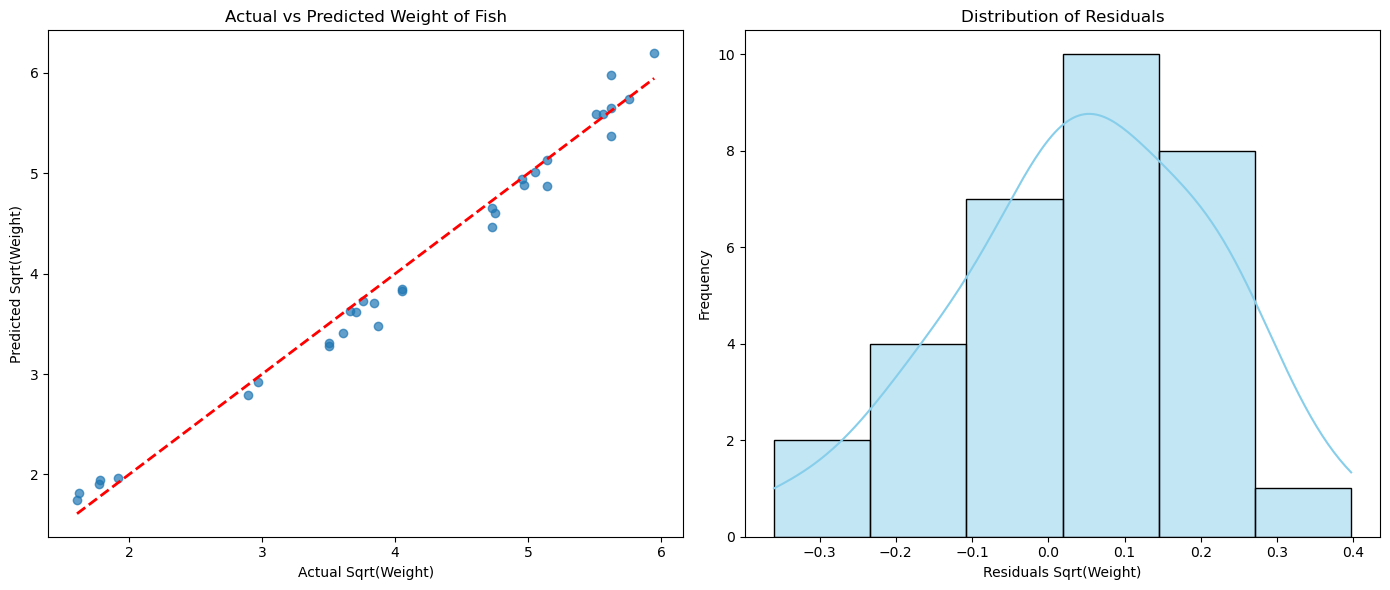

In [421]:
# Calculate residuals
residuals = y_test - y_pred

# Create figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Subplot 1: Predicted vs Actual ---
axes[0].scatter(y_test, y_pred, alpha=0.7)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Sqrt(Weight)')
axes[0].set_ylabel('Predicted Sqrt(Weight)')
axes[0].set_title('Actual vs Predicted Weight of Fish')

# --- Subplot 2: Residuals distribution ---
sns.histplot(residuals, kde=True, ax=axes[1], color='skyblue', edgecolor='black')
axes[1].set_xlabel('Residuals Sqrt(Weight)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals')

plt.tight_layout()
plt.show()

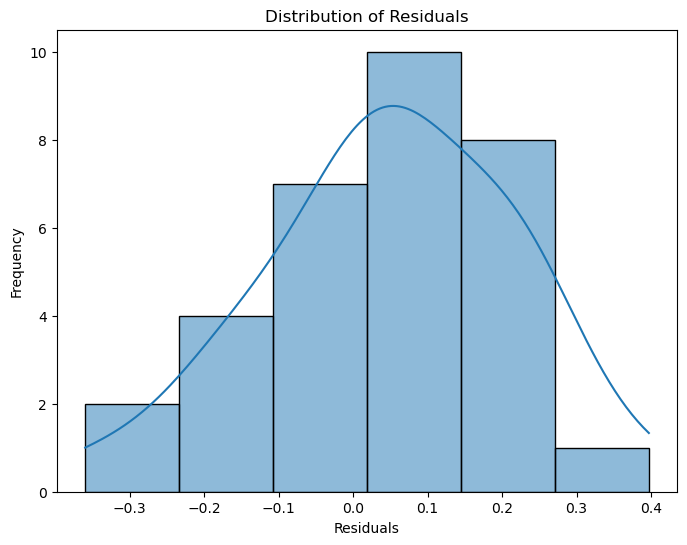

In [422]:
# Residuals plot checking for normal distribution of residuals
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

### Final summary

The linear regression model was trained to predict the square root transformed weight of the fish species under consideration based on their cross length, weight, and height. The model resulted in an R² score of approximately 0.98 on the test set, which can be interpreted as a strong fit. The residuals were analyzed and found to be approximately normally distributed, suggesting that the model assumptions were reasonably met. Further improvements could involve exploring non-linear models or incorporating additional features (e.g., species as a dummy variable).